In [ ]:
## Alle für das Programm nötigen Imports
### Abschnitt 1
import numpy as np
import matplotlib.pyplot as plt
import random
### Abschnitt 2
import ipywidgets as widgets
from IPython.display import display
### Abschnitt 4
import time
import pandas as pd
### Abschnitt 5
from qiskit_optimization import QuadraticProgram
from qiskit_ibm_runtime import Sampler
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator, Sampler
import time
### Abschnitt 6
import pandas as pd
import matplotlib.pyplot as plt





In [10]:
## Qiskitversoinen abfragen

import qiskit
import qiskit_optimization
import qiskit_ibm_runtime

print("Qiskit:", qiskit.__version__)
print("Qiskit Optimization:", qiskit_optimization.__version__)
print("Qiskit IBM Runtime:", qiskit_ibm_runtime.__version__)


Qiskit: 2.1.1
Qiskit Optimization: 0.6.1
Qiskit IBM Runtime: 0.41.0


Kundenpunkte:
0: [50. 50.]
1: [15.42875781 13.36995607]
2: [36.26854662 67.91088754]
3: [19.44500573 25.12103835]
4: [75.84163915 55.76185896]


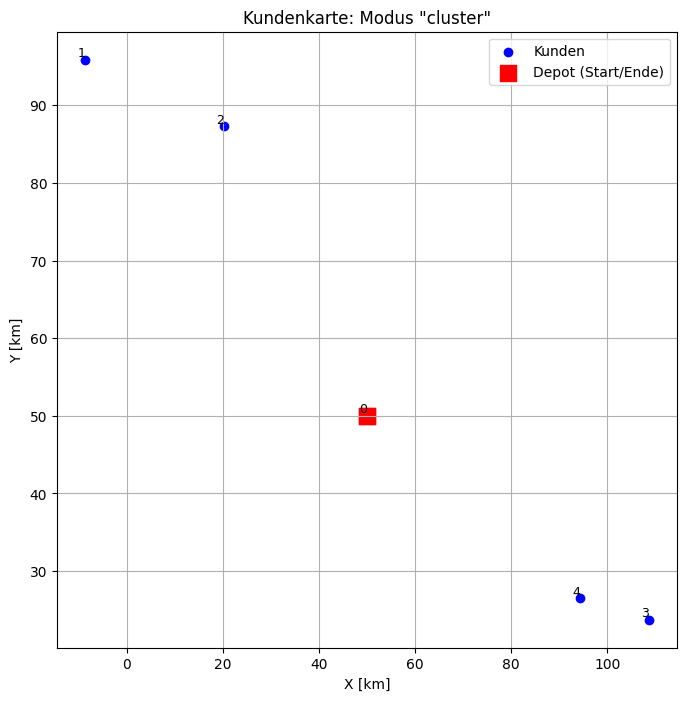

In [70]:
# Abschnitt 1: Kundenpunkte generieren und Depot definieren

## Einstellungen
NUM_CUSTOMERS = 4  # zusätzlich zum Depot = 20 Punkte insgesamt
MAP_SIZE = 100      # 100x100 km Karte
SEED = 66           # Damit alles wiederholbar bleibt

## Schwierigkeitsmodus: 'einfach', 'schwer', 'cluster'
MODE = 'cluster'    # Ändere auf 'einfach', 'schwer' nach Belieben

random.seed(SEED)
np.random.seed(SEED)

def generate_points_small(num_customers=NUM_CUSTOMERS, map_size=MAP_SIZE):
    depot = np.array([map_size//2, map_size//2])
    points = np.random.uniform(0, map_size, (num_customers, 2))
    all_points = np.vstack([depot, points])
    return all_points, depot

points, depot = generate_points_small()

# Prioritätskunde z.B. Kunde 2 (Index 2)
prioritized_idx = 2  

# Zeitfenster (max Minuten bis Prioritätskunde anfahren)
zeitfenster_minutes = 120  
LKW_SPEED = 80  # km/h

print("Kundenpunkte:")
for i, p in enumerate(points):
    print(f"{i}: {p}")
points, depot = generate_points(MODE)

## Visualisierung: Punkte plotten
plt.figure(figsize=(8,8))
plt.scatter(points[1:,0], points[1:,1], c='blue', label='Kunden')
plt.scatter(depot, depot, c='red', s=120, label='Depot (Start/Ende)', marker='s')
for i in range(len(points)):
    plt.text(points[i,0], points[i,1], str(i), fontsize=9, ha='right', va='bottom')
plt.title(f'Kundenkarte: Modus "{MODE}"')
plt.xlabel('X [km]')
plt.ylabel('Y [km]')
plt.legend()
plt.grid(True)
plt.show()



In [30]:
# Abschnitt 2: Eingabe – Priorisierten Kunden & Zeitlimit auswählen



## Dropdown: Wähle Prioritätskunde (außer 0, weil 0 = Depot) 

prioritized_dropdown = widgets.Dropdown(
options=[(f"Kunde {i}", i) for i in range(1, NUM_CUSTOMERS+1)],
value=1,
description='Priorisierter Kunde:'
)

## Zahleneingabe: Nach wie vielen Minuten soll der priorisierte Kunde spätestens angefahren werden?

zeitfenster_field = widgets.IntText(
value=90,
description='Max Minuten bis Stopp:',
)
display(prioritized_dropdown, zeitfenster_field)

Dropdown(description='Priorisierter Kunde:', options=(('Kunde 1', 1), ('Kunde 2', 2), ('Kunde 3', 3), ('Kunde …

IntText(value=90, description='Max Minuten bis Stopp:')

In [71]:
# Abschnitt 3: Matrix für Entfernungen & Fahrtzeit bauen

LKW_SPEED = 80         # km/h
MAX_MINUTES = 250      # max Fahrtzeit in Minuten

## Hilfsfunktion: Distanz in km
def calc_dist(p1, p2):
    return np.linalg.norm(p1 - p2)

dist_matrix = np.zeros((len(points), len(points)))
for i in range(len(points)):
    for j in range(len(points)):
        dist_matrix[i,j] = calc_dist(points[i], points[j])

## Zeitmatrix (Minuten)
time_matrix = dist_matrix / LKW_SPEED * 60

## Für spätere Nutzung in Algorithmen
print("Distanzmatrix und Zeitmatrix bereit!")


Distanzmatrix und Zeitmatrix bereit!


In [72]:
def classical_nearest_neighbor(points, depot_idx, prioritized_idx, zeitfenster_minutes):
    n = len(points)
    visited = set([depot_idx])
    route = [depot_idx]
    current = depot_idx
    total_minutes = 0

    # Besuche Kunden vor Prioritätskunde mit Zeitfenster beachten
    while True:
        if current == prioritized_idx or total_minutes + time_matrix[current, prioritized_idx] > zeitfenster_minutes:
            break
        candidates = [i for i in range(n) if i not in visited and i != prioritized_idx]
        if not candidates:
            break
        next_idx = min(candidates, key=lambda c: time_matrix[current,c])
        route.append(next_idx)
        visited.add(next_idx)
        total_minutes += time_matrix[current, next_idx]
        current = next_idx

    # Prioritätskunde anfahren
    route.append(prioritized_idx)
    visited.add(prioritized_idx)
    total_minutes += time_matrix[current, prioritized_idx]
    current = prioritized_idx

    # Restliche Kunden mit Restzeit besuchen
    while total_minutes + time_matrix[current, depot_idx] < 540:
        candidates = [i for i in range(n) if i not in visited and i != depot_idx]
        if not candidates:
            break
        next_idx = min(candidates, key=lambda c: time_matrix[current,c])
        if total_minutes + time_matrix[current, next_idx] + time_matrix[next_idx, depot_idx] > 540:
            break
        route.append(next_idx)
        visited.add(next_idx)
        total_minutes += time_matrix[current, next_idx]
        current = next_idx

    # Zurück zum Depot
    route.append(depot_idx)
    total_minutes += time_matrix[current, depot_idx]

    return route, total_minutes

import time
start = time.time()
classical_route, classical_time = classical_nearest_neighbor(points, 0, prioritized_idx, zeitfenster_minutes)
classical_runtime_ms = int((time.time() - start)*1000)

print(f"Klassische Route: {classical_route}")
print(f"Laufzeit klassisch: {classical_runtime_ms} ms, Gesamtzeit: {classical_time:.2f} min")


Klassische Route: [0, 4, 3, 2, 1, 0]
Laufzeit klassisch: 0 ms, Gesamtzeit: 208.68 min


In [ ]:
# Abschnitt 5: Vollständiges TSP-Mapping mit QAOA-Ausführung auf IBM Hardware und Ergebnisabspeicherung

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
import numpy as np
import pandas as pd
import time


def create_tsp_with_priority(points, prioritized_idx, zeitfenster_minutes, lkw_speed):
    num_nodes = len(points)
    qp = QuadraticProgram()

    # Binärvariablen x_{i,j} für Kanten i→j
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                qp.binary_var(name=f"x_{i}_{j}")

    # Reihenfolgenvariablen u_i (Depot u_0 = 0)
    for i in range(1, num_nodes):
        qp.integer_var(name=f"u_{i}", lowerbound=1, upperbound=num_nodes-1)

    # Zielfunktion: Minimierung der Gesamtdistanz
    obj = {}
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                dist = np.linalg.norm(points[i] - points[j])
                obj[f"x_{i}_{j}"] = dist
    qp.minimize(linear=obj)

    # Jede Stadt genau einmal verlassen
    for i in range(num_nodes):
        qp.linear_constraint(
            sense="==",
            rhs=1,
            linear={f"x_{i}_{j}": 1 for j in range(num_nodes) if i != j},
            name=f"leave_{i}"
        )

    # Jede Stadt genau einmal betreten
    for j in range(num_nodes):
        qp.linear_constraint(
            sense="==",
            rhs=1,
            linear={f"x_{i}_{j}": 1 for i in range(num_nodes) if i != j},
            name=f"enter_{j}"
        )

    # MTZ-Constraints (Subtour-Eliminierung)
    for i in range(1, num_nodes):
        for j in range(1, num_nodes):
            if i != j:
                qp.linear_constraint(
                    sense="<=",
                    rhs=num_nodes - 2,
                    linear={
                        f"u_{i}": 1,
                        f"u_{j}": -1,
                        f"x_{i}_{j}": num_nodes - 1
                    },
                    name=f"mtz_{i}_{j}"
                )

    # Prioritätskunde: Reihenfolge begrenzen entsprechend Zeitfenster
    max_stops = int(np.floor((zeitfenster_minutes / 60) * lkw_speed))
    qp.linear_constraint(
        sense="<=",
        rhs=max_stops,
        linear={f"u_{prioritized_idx}": 1},
        name="priority_time"
    )

    return qp

# --- Konfiguration ---

API_TOKEN = "hc_jCRxZWVqz8KZuZY58kmtbiC81I1tuGuKrU4a-VOGF"
INSTANCE = "crn:v1:bluemix:public:quantum-computing:us-east:a/71e0d8f4996f4919a7a1f5a17593eac9:817179d7-c733-47f0-89fa-64f2696e053c::"
CHANNEL = "ibm_quantum_platform"
BACKEND = "ibm_torino"
LKW_SPEED = 80 # km/h

# IBM Runtime-Service initialisieren
service = QiskitRuntimeService(channel=CHANNEL, token=API_TOKEN, instance=INSTANCE)
backend = service.backend(BACKEND)

# Erzeuge das TSP-QuadraticProgram mit Constraints
qp = create_tsp_with_priority(points, prioritized_dropdown.value, zeitfenster_field.value, LKW_SPEED)

# QUBO-Konvertierung: Integer-Variablen in binäre Variablen und Constraints als Penaltys ins Ziel
converter = QuadraticProgramToQubo()
qubo = converter.convert(qp)

# Umwandlung in Pauli-Operator für QAOA
qubit_op, _ = qubo.to_ising()

# Setup QAOA mit Sampler und Optimizer
sampler = Sampler(mode=backend)
optimizer = COBYLA(maxiter=100)
qaoa = QAOA(sampler=sampler, optimizer=optimizer)

# Quantum-Optimierung starten und Laufzeit messen
start = time.time()
result = qaoa.compute_minimum_eigenvalue(qubit_op)
runtime_qaoa_ms = int((time.time() - start) * 1000)

# Ergebnis: Wahrscheinlichster Bitstring extrahieren
bitstring = "".join([str(int(b)) for b in result.eigenstate])

# Bitstring in Routing-Matrix dekodieren
num_nodes = len(points)
edge_matrix = np.zeros((num_nodes, num_nodes), dtype=int)
idx = 0
for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j:
            edge_matrix[i, j] = int(bitstring[idx])
            idx += 1

# Route rekonstruieren aus der edge_matrix
route_qaoa = []
current = 0
visited = set([current])
for _ in range(num_nodes):
    nexts = np.where(edge_matrix[current] == 1)[0]
    next_city = [n for n in nexts if n not in visited]
    if next_city:
        next_city = next_city
        route_qaoa.append(next_city)
        visited.add(next_city)
        current = next_city
    else:
        break

route_qaoa =  + route_qaoa  # Depot vorne anfügen

# Ergebnis als CSV speichern
route_qaoa_df = pd.DataFrame({'Index': route_qaoa})
route_qaoa_df.to_csv('qaoa_route.csv', index=False)

print(f"QAOA-Job abgeschlossen! Berechnungszeit: {runtime_qaoa_ms} ms")


ImportError: cannot import name 'BaseSampler' from 'qiskit.primitives' (c:\Users\juanc\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\Python_JNotebook\Qiskit\qiskit_env\lib\site-packages\qiskit\primitives\__init__.py)

In [ ]:
help(Sampler)

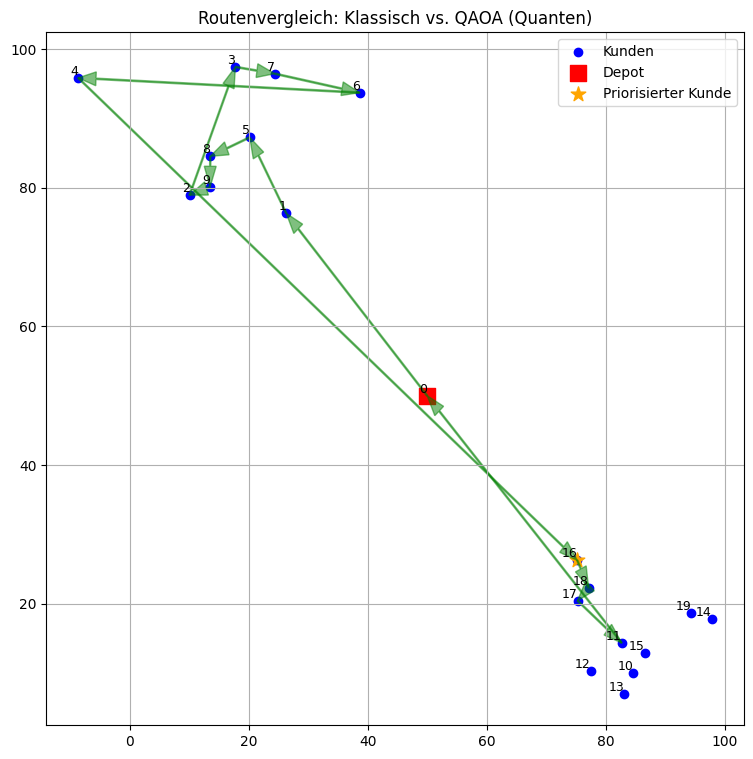

In [58]:
# Abschnitt 6: Ergebnisse laden und Routen plotten

route_df = pd.read_csv('classical_route.csv')
route_qaoa_df = pd.read_csv('qaoa_route.csv')

def plot_routes(points, route_indices, route_qaoa_indices, depot_idx, prioritized_idx):
    plt.figure(figsize=(9,9))
    plt.scatter(points[1:,0], points[1:,1], label='Kunden', color='blue')
    plt.scatter(points[depot_idx,0], points[depot_idx,1], s=120, marker='s', color='red', label='Depot')
    plt.scatter(points[prioritized_idx,0], points[prioritized_idx,1], s=120, marker='*', color='orange', label='Priorisierter Kunde')
    for idx in range(len(points)):
        plt.text(points[idx,0], points[idx,1], str(idx), fontsize=9, ha='right', va='bottom')
    ## Klassische Route zeichnen (dünne Pfeile)
    for i in range(len(route_indices)-1):
        plt.arrow(
            points[route_indices[i],0], points[route_indices[i],1],
            points[route_indices[i+1],0] - points[route_indices[i],0],
            points[route_indices[i+1],1] - points[route_indices[i],1],
            color='green', width=0.2, length_includes_head=True, head_width=2, alpha=0.5
        )
    ## QAOA-Route zeichnen (andersfarbig)
    for i in range(len(route_qaoa_indices)-1):
        plt.arrow(
            points[route_qaoa_indices[i],0], points[route_qaoa_indices[i],1],
            points[route_qaoa_indices[i+1],0] - points[route_qaoa_indices[i],0],
            points[route_qaoa_indices[i+1],1] - points[route_qaoa_indices[i],1],
            color='purple', width=0.2, length_includes_head=True, head_width=2, alpha=0.5
        )
    plt.title('Routenvergleich: Klassisch vs. QAOA (Quanten)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_routes(
    points,
    route_df['Index'].tolist(),
    route_qaoa_df['Index'].tolist(),
    depot_idx,
    prioritized_idx
)


In [60]:
# Abschnitt 7: Vergleich und Performance-Analyse

print(f"Klassischer Algorithmus: Fahrtzeit genutzt = {total_time:.1f} Min, Berechnungszeit = {runtime_ms} ms")
print(f"Quanten-QAOA-Algorithmus: Fahrtzeit genutzt = {total_qaoa_time:.1f} Min, Berechnungszeit = {runtime_qaoa_ms} ms")
if abs(total_qaoa_time-MAX_MINUTES) < abs(total_time-MAX_MINUTES):
    print("QAOA (Quanten) nutzt die verfügbare Zeit besser aus!")
else:
    print("Klassischer Algorithmus nutzt die Zeit besser – aber je nach Instanz kann sich das ändern!")

#💡💡   Hinweise für dich  💡💡
#💡Nutze jeden Block einzeln in deinem Jupyter Notebook. Passe `API_TOKEN`, `INSTANCE`, und `BACKEND` für den QAOA-Teil an!
#💡Das QAOA-Mapping (QuadraticProgram) ist das mathematisch aufwendigste Segment. Dafür gibt es Qiskit-TSP-Beispiele als Vorlage.
#💡Die Routen werden als CSV gespeichert und dann direkt wieder visualisiert.
#💡Die Visualisierung zeigt Pfeile, Depot, Kunde und Prioritätskunde und ist farbkodiert.


Klassischer Algorithmus: Fahrtzeit genutzt = 244.4 Min, Berechnungszeit = 248 ms
Quanten-QAOA-Algorithmus: Fahrtzeit genutzt = 0.0 Min, Berechnungszeit = 0 ms
Klassischer Algorithmus nutzt die Zeit besser – aber je nach Instanz kann sich das ändern!
